<a id="inicio"></a>
# Análisis de dependencias y vulnerabilidades

Este notebook corresponde a la **tercera parte** de la actividad ***Tarea 3: SBOMs + Análisis de Vulnerabilidades***. El objetivo es analizar las dependencias y vulnerabilidades que se detectaron sobre los repositorios de la organización **sveltejs**.

## Cómo se reproduce

1. Clonar el repositorio.
2. `git submodule update --init --recursive` para traer los 17 repos.
3. `uv sync` para instalar dependencias de Python.
4. Correr los scripts en este orden:
   ```bash
   uv run python scripts/generate_sboms.py
   uv run python scripts/generate_grype.py
   uv run python scripts/generate_codeql.py
   ```
5. Abrir este notebook (`uv run jupyter lab nbs/analisis_cuantitativo.ipynb`) y
   ejecutar *Run All*.



<a id="indice"></a>
## Índice

- [Glosario](#glosario)
  - [Sobre dependencias y SBOM](#glosario-sbom)
  - [Sobre vulnerabilidades](#glosario-vulns)
  - [Herramientas usadas](#glosario-herramientas)
- [1. Preparar el entorno y cargar los datos](#seccion-1)
  - [1.1 Importar librerías y ubicar el proyecto](#seccion-1-1)
  - [1.2 Revisar qué archivos hay disponibles](#seccion-1-2)
  - [1.3 Cargar todo en tres tablas de pandas](#seccion-1-3)
  - [1.4 Resumen general](#seccion-1-4)
- [2. Análisis de dependencias (SBOM / Syft)](#seccion-2)
  - [2.1 Tipos de artefactos](#seccion-2-1)
  - [2.2 Lenguajes detectados](#seccion-2-2)
  - [2.3 Licencias más usadas](#seccion-2-3)
  - [2.4 Dependencias compartidas entre repositorios](#seccion-2-4)
- [3. Vulnerabilidades en dependencias (Grype)](#seccion-3)
  - [3.1 Vulnerabilidades por severidad (total)](#seccion-3-1)
  - [3.2 Vulnerabilidades por repositorio](#seccion-3-2)
  - [3.3 Paquetes con más vulnerabilidades](#seccion-3-3)
  - [3.4 CVEs / GHSAs más frecuentes](#seccion-3-4)
- [4. Hallazgos en el código fuente (CodeQL)](#seccion-4)
  - [4.1 Hallazgos por nivel](#seccion-4-1)
  - [4.2 Hallazgos por repositorio](#seccion-4-2)
  - [4.3 Reglas CodeQL más frecuentes](#seccion-4-3)
  - [4.4 Archivos con más hallazgos](#seccion-4-4)
- [5. Cruce SBOM ↔ Grype](#seccion-5)
- [6. Análisis de los resultados y conclusión](#seccion-7)

<a id="glosario"></a>
## Glosario

Estas definiciones sirven de referencia. Si aparece un término nuevo durante
la lectura, se puede volver acá.

<a id="glosario-sbom"></a>
### Sobre dependencias y SBOM

- **SBOM** (*Software Bill of Materials*): lista de todas las dependencias
  que usa un proyecto, parecido a la lista de ingredientes de un producto.
- **Dependencia**: librería externa que un proyecto necesita para funcionar
  (por ejemplo, `react` o `lodash`).
- **Artefacto**: cada elemento que Syft detecta dentro de un repo. Puede ser
  una dependencia, un workflow de GitHub, un binario, etc.
- **SCA** (*Software Composition Analysis*): análisis de los componentes
  externos que usa un proyecto. Es lo que hacen Syft y Grype.
- **SPDX**: estándar para nombrar licencias de software (por ejemplo, `MIT`,
  `Apache-2.0`).
- **DataFrame**: tabla en memoria de la librería `pandas`. Funciona como una
  hoja de cálculo de Excel, pero se manipula con código Python (filtrar,
  agrupar, contar). Es la forma en que este notebook maneja los datos de
  los JSON.

<a id="glosario-vulns"></a>
### Sobre vulnerabilidades

- **Vulnerabilidad**: falla de seguridad conocida en una dependencia o en el
  código.
- **CVE / GHSA**: identificadores públicos de vulnerabilidades. **CVE** es el
  estándar global; **GHSA** es el de GitHub Security Advisories.
- **NVD** (*National Vulnerability Database*): base de datos pública de
  vulnerabilidades mantenida por el gobierno de Estados Unidos. Grype la
  consulta.
- **CVSS**: puntaje de 0 (sin impacto) a 10 (crítico) que mide qué tan grave
  es una vulnerabilidad.
- **Severidad**: categoría derivada del CVSS (*critical*, *high*, *medium*,
  *low*).
- **Remediación / `fix_version`**: versión del paquete en la que la
  vulnerabilidad ya está corregida. Actualizar a esa versión "remedia" el
  problema.
- **SARIF**: formato estándar en el que CodeQL entrega sus hallazgos.

<a id="glosario-herramientas"></a>
### Herramientas usadas

- **Syft**: genera el SBOM (lista dependencias de cada repo).
- **Grype**: revisa si esas dependencias tienen vulnerabilidades conocidas
  contra bases como NVD o GHSA.
- **CodeQL**: revisa el código fuente y encuentra problemas de seguridad por
  análisis estático.
- **pandas** y **matplotlib**: librerías de Python para manejar tablas y
  graficar, usadas dentro de este notebook.


<a id="seccion-1"></a>
## 1. Preparar el entorno y cargar los datos


<a id="seccion-1-1"></a>
### 1.1 Importar librerías y ubicar el proyecto

Se importa `pandas` para manejar tablas y matplotlib` para generar graficos. 
La sig funcion busca la raiz del proyecto para utilizarla en el codigo, así las rutas funcionan sin importar desde dónde se
abra el archivo.


In [163]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root(start: Path) -> Path:
    """Sube por los padres hasta encontrar la raíz del proyecto."""
    for candidato in [start, *start.parents]:
        if (candidato / "pyproject.toml").exists() and (candidato / "data").exists():
            return candidato
    raise RuntimeError("No se encontró la raíz del proyecto")


PROJECT_ROOT = _find_project_root(Path.cwd())
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

print(f"Raíz del proyecto:       {PROJECT_ROOT}")
print(f"Carpeta de resultados:   {RESULTS_DIR}")

Raíz del proyecto:       /workspaces/CiberSeg-T3
Carpeta de resultados:   /workspaces/CiberSeg-T3/data/results


<a id="seccion-1-2"></a>
### 1.2 Revisar qué archivos hay disponibles

Por cada repositorio se esperan como minimo tres archivos JSON dentro de `data/results/`:

| Sufijo           | Quién lo genera      | Qué contiene                           |
|------------------|----------------------|----------------------------------------|
| `*-sbom.json`    | Syft                 | lista de dependencias del repo         |
| `*-grype.json`   | Grype                | vulnerabilidades de esas dependencias  |
| `*-codeql.json`  | CodeQL               | hallazgos de análisis estático         |

Si falta alguno, se avisa qué script hay que correr para generarlo.


In [164]:
sbom_files = sorted(RESULTS_DIR.glob("*-sbom.json"))
grype_files = sorted(RESULTS_DIR.glob("*-grype.json"))
codeql_files = sorted(RESULTS_DIR.glob("*-codeql.json"))

print(f"SBOMs:   {len(sbom_files):>3} archivos")
print(f"Grype:   {len(grype_files):>3} archivos")
print(f"CodeQL:  {len(codeql_files):>3} archivos")

faltantes = []
if not sbom_files:
    faltantes.append("uv run python scripts/generate_sboms.py")
if not grype_files:
    faltantes.append("uv run python scripts/generate_grype.py")
if not codeql_files:
    faltantes.append("uv run python scripts/generate_codeql.py")

if faltantes:
    print("\nFaltan archivos. Ejecutar desde la raíz del proyecto:")
    for cmd in faltantes:
        print(f"  {cmd}")

SBOMs:    18 archivos
Grype:    18 archivos
CodeQL:   18 archivos


<a id="seccion-1-3"></a>
### 1.3 Cargar todo en tres tablas de pandas

Hasta ahora solo sabemos **qué archivos existen**, pero todavía no leímos su
contenido. En este paso se abren los JSON y todo lo que hay dentro se junta
en **tres tablas** en memoria, una por tipo de análisis:

| Tabla           | Viene de         | Qué hay en cada fila                          |
|-----------------|------------------|-----------------------------------------------|
| `df_artefactos` | archivos SBOM    | una dependencia detectada por Syft            |
| `df_vulns`      | archivos Grype   | una vulnerabilidad encontrada en un paquete   |
| `df_codeql`     | archivos CodeQL  | un hallazgo del análisis estático             |

Se generan estas tablas para poder realizar los analisis mucho mas rapido ya que realizar estos analisis leyendo constantemente los archivos json generados requeriria mucho más recursos y tiempo que lo necesario.


In [165]:
def _repo_name(path: Path, sufijo: str) -> str:
    return path.stem.removesuffix(sufijo)


def _cargar_lista(archivos, clave: str, sufijo: str) -> pd.DataFrame:
    """Lee cada JSON y junta el contenido de `data[clave]` en una sola tabla."""
    marcos = []
    for archivo in archivos:
        try:
            contenido = json.loads(archivo.read_text(encoding="utf-8"))
        except json.JSONDecodeError as error:
            print(f"[warn] {archivo.name}: JSON inválido ({error})")
            continue
        registros = contenido.get(clave, []) or []
        if not registros:
            continue
        if clave == "artifacts":
            df = pd.json_normalize(registros)
        else:
            df = pd.DataFrame(registros)
        df["repo"] = _repo_name(archivo, sufijo)
        marcos.append(df)
    if not marcos:
        return pd.DataFrame()
    return pd.concat(marcos, ignore_index=True, sort=False)


df_artefactos = _cargar_lista(sbom_files, "artifacts", "-sbom")
df_vulns = _cargar_lista(grype_files, "vulnerabilities", "-grype")
df_codeql = _cargar_lista(codeql_files, "issues", "-codeql")

print(f"Artefactos (SBOM):       {len(df_artefactos):>6} filas")
print(f"Vulnerabilidades:        {len(df_vulns):>6} filas")
print(f"Hallazgos CodeQL:        {len(df_codeql):>6} filas")

Artefactos (SBOM):         7769 filas
Vulnerabilidades:           376 filas
Hallazgos CodeQL:          2408 filas


<a id="seccion-1-4"></a>
### 1.4 Resumen general

Dandole una primera vista a el analisis realizado, vemos la cantidad de dependencias (o artefactos), vulnerabilidades y los hallazgos encontrados en cada uno de los repositorios.

In [166]:
serie_art = df_artefactos["repo"].value_counts(
) if not df_artefactos.empty else pd.Series(dtype=int)
serie_vuln = df_vulns["repo"].value_counts(
) if not df_vulns.empty else pd.Series(dtype=int)
serie_cql = df_codeql["repo"].value_counts(
) if not df_codeql.empty else pd.Series(dtype=int)

resumen = (
    pd.concat(
        {
            "artefactos": serie_art,
            "vulnerabilidades": serie_vuln,
            "hallazgos_codeql": serie_cql,
        },
        axis=1,
    )
    .fillna(0)
    .astype(int)
    .sort_values("artefactos", ascending=False)
)
resumen

,artefactos,vulnerabilidades,hallazgos_codeql
repo,,,
kit,1045,7,177
eslint-plugin-svelte,939,52,39
svelte-eslint-parser,831,65,7
ai-tools,815,63,4
svelte.dev,727,12,37
vite-plugin-svelte,677,15,17
svelte,568,17,284
cli,467,16,41
language-tools,457,47,1592


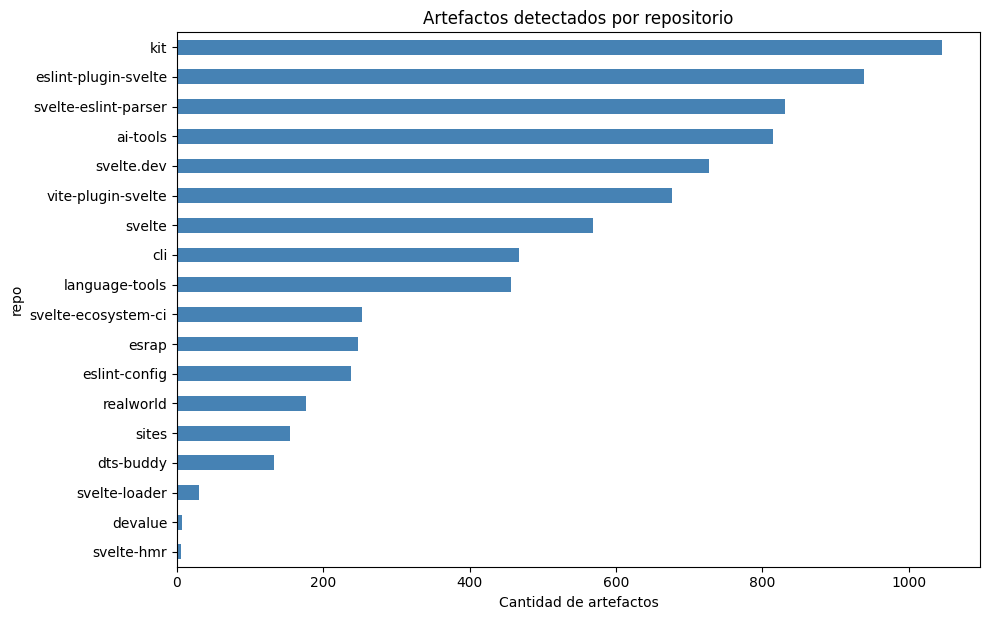

In [167]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(resumen))))
resumen["artefactos"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Cantidad de artefactos")
ax.set_title("Artefactos detectados por repositorio")
plt.tight_layout()
plt.show()

<a id="seccion-2"></a>
## 2. Análisis de dependencias (SBOM / Syft)

En esta sección se revisan las dependencias: cuántas hay, de qué tipo, en qué
lenguajes, con qué licencias y cuáles se repiten en varios repositorios.


<a id="seccion-2-1"></a>
### 2.1 Tipos de artefactos

Syft no solo detecta librerías: también encuentra workflows de GitHub,
archivos de configuración, binarios, etc. A cada se le asigna su `type` para clasificarlo


,cantidad
type,
npm,7553
github-action,214
github-action-workflow,2


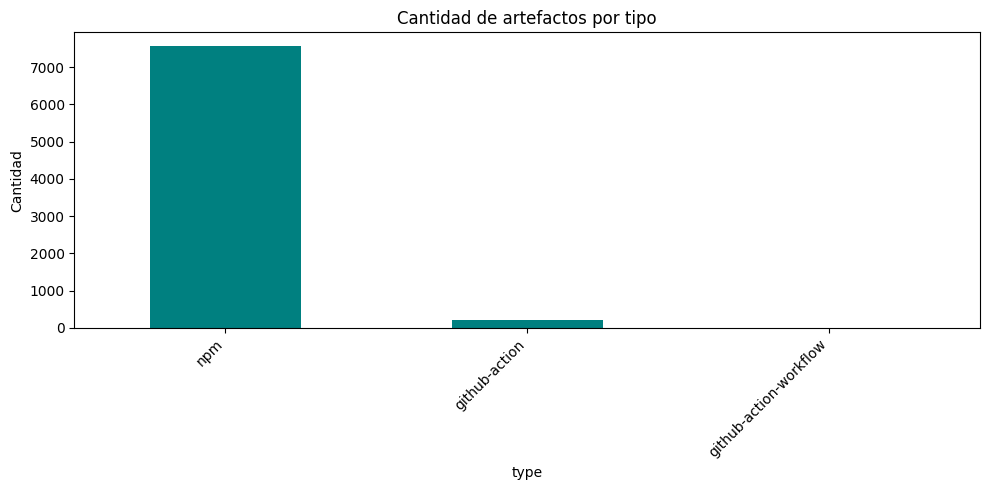

In [168]:
if df_artefactos.empty:
    print("No hay SBOMs cargados.")
else:
    tipos = df_artefactos["type"].fillna("unknown").value_counts()
    display(tipos.to_frame("cantidad"))

    fig, ax = plt.subplots(figsize=(10, 5))
    tipos.plot(kind="bar", ax=ax, color="teal")
    ax.set_title("Cantidad de artefactos por tipo")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    plt.tight_layout()
    plt.show()

<a id="seccion-2-2"></a>
### 2.2 Lenguajes detectados

Analisamos los lenguajes de programacion que aparecen en las dependencias.


,cantidad
language,
javascript,7553
N/A,216


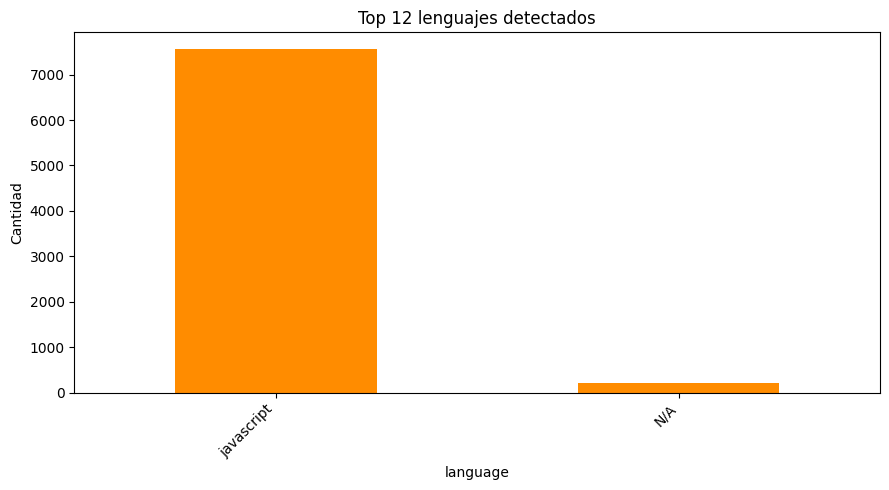

In [169]:
if df_artefactos.empty or "language" not in df_artefactos.columns:
    print("No hay datos de lenguaje.")
else:
    lenguajes = (
        df_artefactos["language"]
        .replace({"": "N/A"})
        .fillna("N/A")
        .value_counts()
        .head(12)
    )
    display(lenguajes.to_frame("cantidad"))

    fig, ax = plt.subplots(figsize=(9, 5))
    lenguajes.plot(kind="bar", ax=ax, color="darkorange")
    ax.set_title("Top 12 lenguajes detectados")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    plt.tight_layout()
    plt.show()

<a id="seccion-2-3"></a>
### 2.3 Licencias más usadas

Cada dependencia puede declarar una o más licencias. Se toma el código SPDX
(por ejemplo `MIT`, `Apache-2.0`) y se cuenta cuántas veces aparece.


,cantidad
licenses,
MIT,2


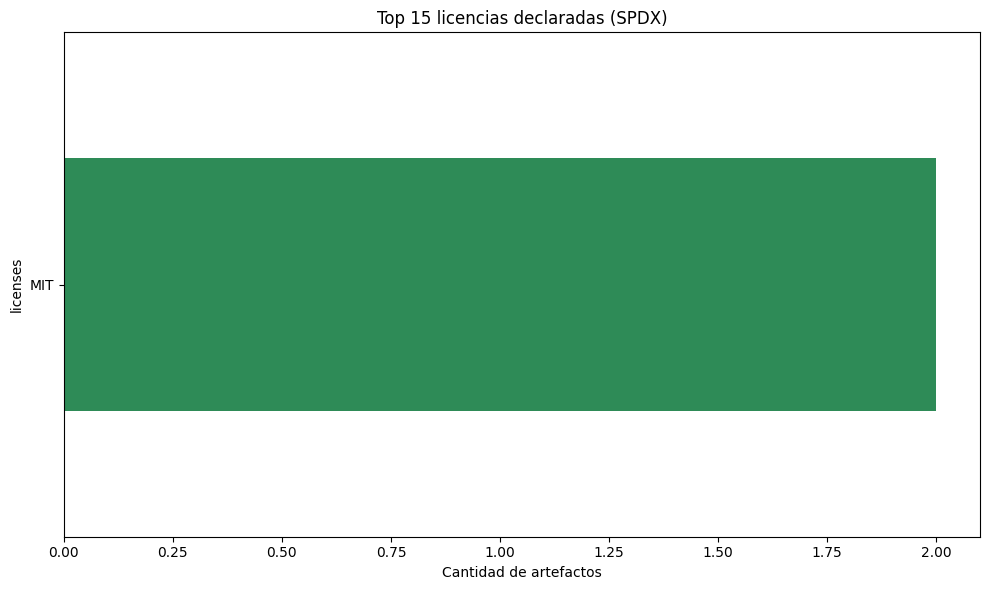

In [170]:
def _licencias_spdx(valor) -> list[str]:
    if not isinstance(valor, list):
        return []
    etiquetas = []
    for entrada in valor:
        if isinstance(entrada, dict):
            etiqueta = entrada.get("spdxExpression") or entrada.get(
                "value") or "UNKNOWN"
            if etiqueta:
                etiquetas.append(etiqueta)
    return etiquetas


if df_artefactos.empty or "licenses" not in df_artefactos.columns:
    print("No hay datos de licencias.")
else:
    licencias = (
        df_artefactos["licenses"]
        .map(_licencias_spdx)
        .explode()
        .dropna()
    )
    licencias = licencias[licencias != ""].value_counts().head(15)
    display(licencias.to_frame("cantidad"))

    fig, ax = plt.subplots(figsize=(10, 6))
    licencias.sort_values().plot(kind="barh", ax=ax, color="seagreen")
    ax.set_title("Top 15 licencias declaradas (SPDX)")
    ax.set_xlabel("Cantidad de artefactos")
    plt.tight_layout()
    plt.show()

<a id="seccion-2-4"></a>
### 2.4 Dependencias compartidas entre repositorios

Aquí se busca qué dependencias aparecen en varios repositorios a la vez.

In [171]:
if df_artefactos.empty:
    print("No hay SBOMs cargados.")
else:
    reutilizados = (
        df_artefactos.dropna(subset=["name"])
        .groupby("name")
        .agg(repos=("repo", "nunique"), apariciones=("repo", "count"))
        .sort_values(["repos", "apariciones"], ascending=False)
        .head(20)
    )
    display(reutilizados)

,repos,apariciones
name,,
actions/checkout,16,61
actions/setup-node,16,57
picomatch,15,32
prettier,15,27
semver,15,22
acorn,15,21
magic-string,15,20
@jridgewell/trace-mapping,15,19
@types/estree,15,19


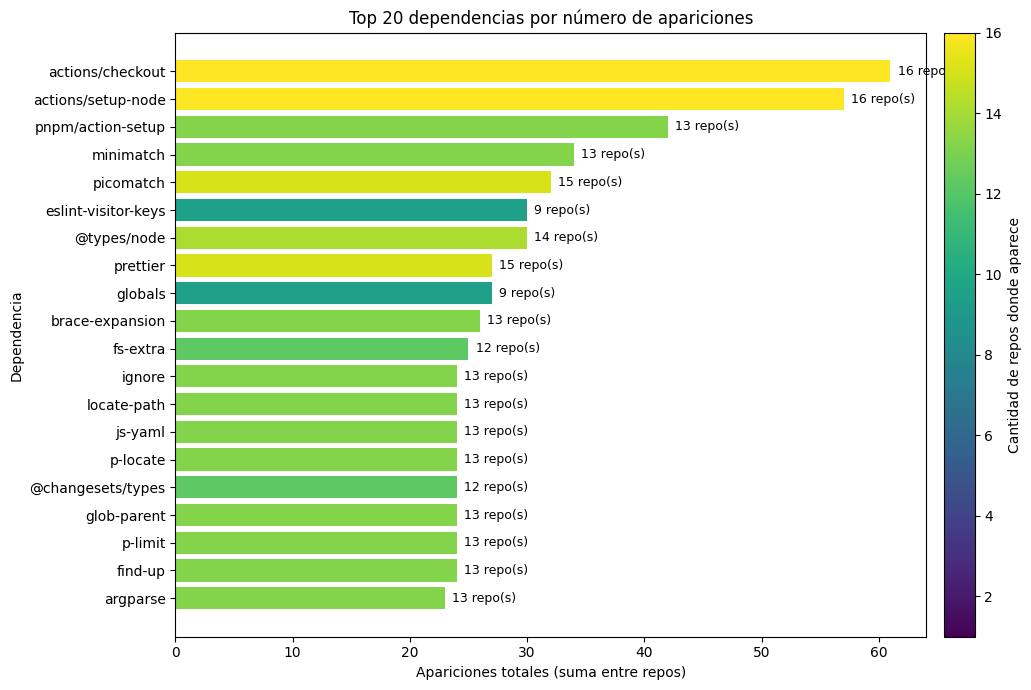

In [172]:
if df_artefactos.empty:
    print("No hay SBOMs cargados.")
else:
    top_apariciones = (
        df_artefactos.dropna(subset=["name"])
        .groupby("name")
        .agg(apariciones=("repo", "count"), repos=("repo", "nunique"))
        .sort_values("apariciones", ascending=False)
        .head(20)
        .sort_values("apariciones")
    )

    # Intensidad de color proporcional al número de repos donde aparece
    max_repos = top_apariciones["repos"].max()
    colores = plt.cm.viridis(top_apariciones["repos"] / max_repos)

    fig, ax = plt.subplots(figsize=(11, 7))
    barras = ax.barh(top_apariciones.index,
                     top_apariciones["apariciones"], color=colores)
    ax.set_title("Top 20 dependencias por número de apariciones")
    ax.set_xlabel("Apariciones totales (suma entre repos)")
    ax.set_ylabel("Dependencia")

    # Etiqueta al final de cada barra: cuántos repos la usan
    for barra, repos_count in zip(barras, top_apariciones["repos"]):
        ax.text(
            barra.get_width() + max(top_apariciones["apariciones"]) * 0.01,
            barra.get_y() + barra.get_height() / 2,
            f"{repos_count} repo(s)",
            va="center",
            fontsize=9,
        )

    # Barra de color lateral para explicar la intensidad
    sm = plt.cm.ScalarMappable(
        cmap="viridis", norm=plt.Normalize(vmin=1, vmax=max_repos))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Cantidad de repos donde aparece")

    plt.tight_layout()
    plt.show()

<a id="seccion-3"></a>
## 3. Vulnerabilidades en dependencias (Grype)

Grype compara cada dependencia contra bases de datos públicas (NVD, GHSA) y
marca las que tienen vulnerabilidades conocidas. Cada fila representa una
coincidencia: "el paquete X versión Y tiene la vulnerabilidad Z".


<a id="seccion-3-1"></a>
### 3.1 Vulnerabilidades por severidad (total)

Se cuenta cuántas vulnerabilidades hay en total y cómo se reparten entre
*critical*, *high*, *medium* y *low*.


,cantidad
vuln_severity,
low,376


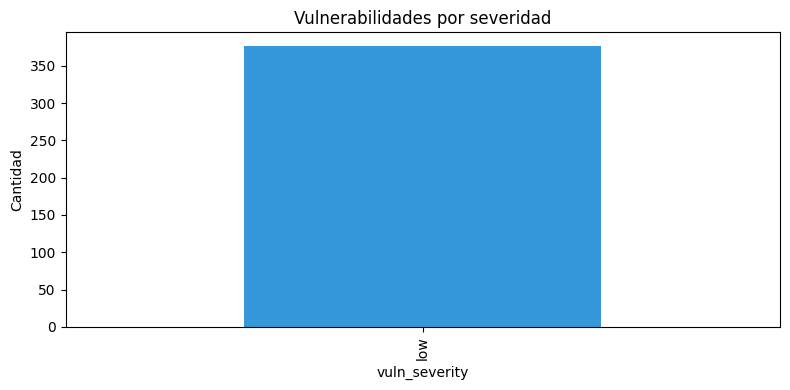

In [173]:
ORDEN_SEVERIDAD = ["critical", "high",
                   "medium", "low", "negligible", "unknown"]
COLOR_SEVERIDAD = {
    "critical": "#c0392b",
    "high": "#e67e22",
    "medium": "#f1c40f",
    "low": "#3498db",
    "negligible": "#95a5a6",
    "unknown": "#7f8c8d",
}

if df_vulns.empty:
    print("No hay vulnerabilidades cargadas.")
else:
    severidades = (
        df_vulns["vuln_severity"]
        .fillna("unknown")
        .str.lower()
        .value_counts()
        .reindex(ORDEN_SEVERIDAD)
        .dropna()
        .astype(int)
    )
    display(severidades.to_frame("cantidad"))

    fig, ax = plt.subplots(figsize=(8, 4))
    severidades.plot(
        kind="bar",
        ax=ax,
        color=[COLOR_SEVERIDAD[s] for s in severidades.index],
    )
    ax.set_title("Vulnerabilidades por severidad")
    ax.set_ylabel("Cantidad")
    plt.tight_layout()
    plt.show()

<a id="seccion-3-2"></a>
### 3.2 Vulnerabilidades por repositorio

Un gráfico de barras apiladas: cada barra es un repositorio y cada color una
severidad. Así se ve rápido qué repos están peor.


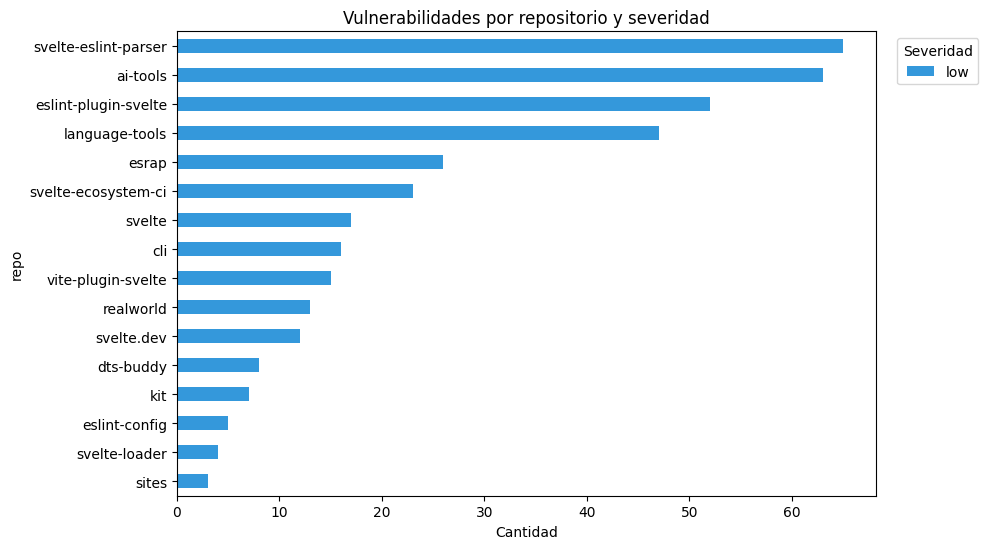

vuln_severity,low,total
repo,,
svelte-eslint-parser,65,65
ai-tools,63,63
eslint-plugin-svelte,52,52
language-tools,47,47
esrap,26,26
svelte-ecosystem-ci,23,23
svelte,17,17
cli,16,16
vite-plugin-svelte,15,15


In [174]:
if df_vulns.empty:
    print("No hay vulnerabilidades cargadas.")
else:
    pivote = (
        df_vulns.assign(
            vuln_severity=df_vulns["vuln_severity"].fillna(
                "unknown").str.lower()
        )
        .pivot_table(
            index="repo",
            columns="vuln_severity",
            values="vuln_id",
            aggfunc="count",
            fill_value=0,
        )
    )
    orden_presentes = [c for c in ORDEN_SEVERIDAD if c in pivote.columns]
    pivote = pivote[orden_presentes]
    pivote = pivote.loc[pivote.sum(axis=1).sort_values(ascending=True).index]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(pivote))))
    pivote.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=[COLOR_SEVERIDAD[s] for s in orden_presentes],
    )
    ax.set_title("Vulnerabilidades por repositorio y severidad")
    ax.set_xlabel("Cantidad")
    ax.legend(title="Severidad", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    display(pivote.assign(total=pivote.sum(axis=1)
                          ).sort_values("total", ascending=False))

<a id="seccion-3-3"></a>
### 3.3 Paquetes con más vulnerabilidades

Los paquetes que acumulan más vulnerabilidades son candidatos obvios a
actualizar o reemplazar.


In [175]:
if df_vulns.empty:
    print("No hay vulnerabilidades cargadas.")
else:
    def _severidad_peor(serie: pd.Series) -> str:
        prioridades = {s: i for i, s in enumerate(ORDEN_SEVERIDAD)}
        limpio = serie.fillna("unknown").str.lower()
        return min(limpio, key=lambda s: prioridades.get(s, 99))

    top_paquetes = (
        df_vulns.groupby("package_name")
        .agg(
            vulnerabilidades=("vuln_id", "count"),
            repos_afectados=("repo", "nunique"),
            peor_severidad=("vuln_severity", _severidad_peor),
        )
        .sort_values(["vulnerabilidades", "repos_afectados"], ascending=False)
        .head(15)
    )
    display(top_paquetes)

,vulnerabilidades,repos_afectados,peor_severidad
package_name,,,
minimatch,56,7,low
picomatch,42,11,low
vite,35,8,low
brace-expansion,24,10,low
svelte,23,5,low
@sveltejs/kit,18,6,low
flatted,16,8,low
devalue,16,4,low
undici,16,3,low


<a id="seccion-3-4"></a>
### 3.4 CVEs / GHSAs más frecuentes

Identifica qué vulnerabilidades específicas aparecen en más repos o en más
paquetes.


In [176]:
if df_vulns.empty:
    print("No hay vulnerabilidades cargadas.")
else:
    top_cves = (
        df_vulns.groupby("vuln_id")
        .agg(
            repos_afectados=("repo", "nunique"),
            paquetes_afectados=("package_name", "nunique"),
            severidad=("vuln_severity", "first"),
        )
        .sort_values(["repos_afectados", "paquetes_afectados"], ascending=False)
        .head(15)
    )
    display(top_cves)

,repos_afectados,paquetes_afectados,severidad
vuln_id,,,
GHSA-3v7f-55p6-f55p,11,1,low
GHSA-c2c7-rcm5-vvqj,11,1,low
GHSA-f886-m6hf-6m8v,10,1,low
GHSA-4w7w-66w2-5vf9,8,1,low
GHSA-rf6f-7fwh-wjgh,8,1,low
GHSA-23c5-xmqv-rm74,7,1,low
GHSA-48c2-rrv3-qjmp,7,1,low
GHSA-7r86-cg39-jmmj,7,1,low
GHSA-pxg6-pf52-xh8x,7,1,low


<a id="seccion-4"></a>
## 4. Hallazgos en el código fuente (CodeQL)

CodeQL revisa el **código fuente** (no las dependencias). Cada hallazgo es una
regla de seguridad que se disparó en un archivo concreto.


<a id="seccion-4-1"></a>
### 4.1 Hallazgos por nivel (*error*, *warning*, *note*)

CodeQL clasifica cada hallazgo con un nivel SARIF. *error* es el más grave.


,cantidad
level,
warning,2408


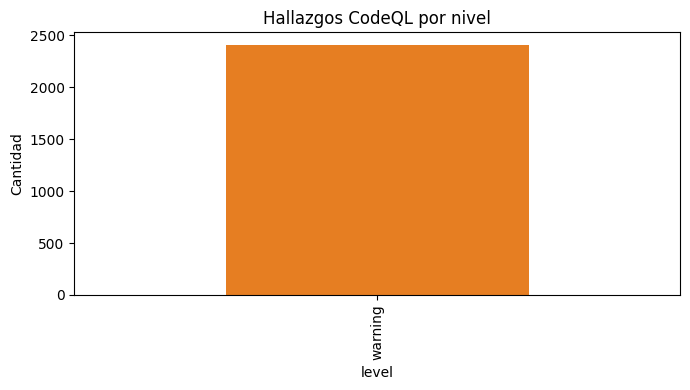

In [177]:
COLOR_NIVEL = {"error": "#c0392b", "warning": "#e67e22", "note": "#3498db"}

if df_codeql.empty:
    print("No hay hallazgos CodeQL cargados.")
else:
    niveles = df_codeql["level"].fillna("unknown").value_counts()
    display(niveles.to_frame("cantidad"))

    fig, ax = plt.subplots(figsize=(7, 4))
    niveles.plot(
        kind="bar",
        ax=ax,
        color=[COLOR_NIVEL.get(n, "#7f8c8d") for n in niveles.index],
    )
    ax.set_title("Hallazgos CodeQL por nivel")
    ax.set_ylabel("Cantidad")
    plt.tight_layout()
    plt.show()

<a id="seccion-4-2"></a>
### 4.2 Hallazgos por repositorio


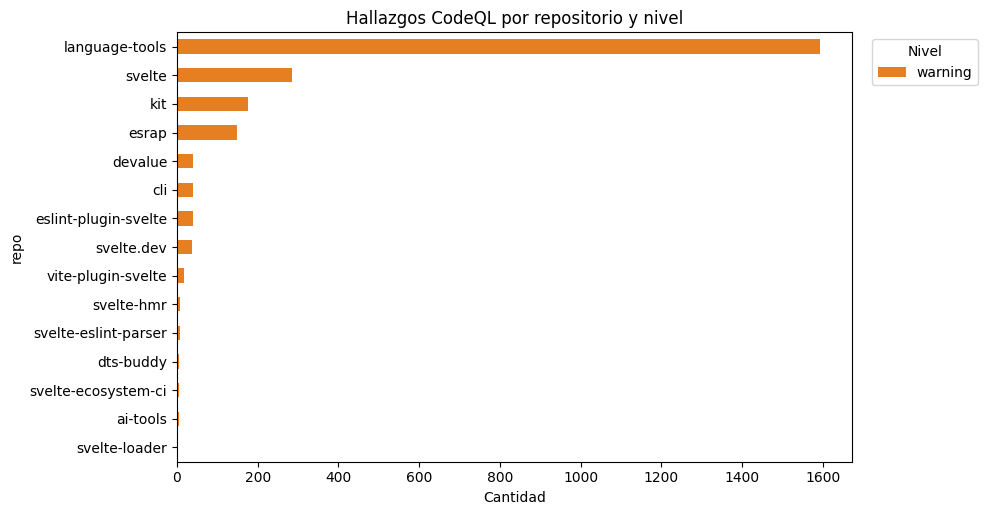

level,warning,total
repo,,
language-tools,1592,1592
svelte,284,284
kit,177,177
esrap,149,149
cli,41,41
devalue,41,41
eslint-plugin-svelte,39,39
svelte.dev,37,37
vite-plugin-svelte,17,17


In [178]:
if df_codeql.empty:
    print("No hay hallazgos CodeQL cargados.")
else:
    pivote_cql = (
        df_codeql.pivot_table(
            index="repo",
            columns="level",
            values="rule_id",
            aggfunc="count",
            fill_value=0,
        )
    )
    orden_cql = [c for c in ["error", "warning", "note"]
                 if c in pivote_cql.columns]
    pivote_cql = pivote_cql[orden_cql]
    pivote_cql = pivote_cql.loc[pivote_cql.sum(
        axis=1).sort_values(ascending=True).index]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(pivote_cql))))
    pivote_cql.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=[COLOR_NIVEL.get(c, "#7f8c8d") for c in orden_cql],
    )
    ax.set_title("Hallazgos CodeQL por repositorio y nivel")
    ax.set_xlabel("Cantidad")
    ax.legend(title="Nivel", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    display(pivote_cql.assign(total=pivote_cql.sum(
        axis=1)).sort_values("total", ascending=False))

<a id="seccion-4-3"></a>
### 4.3 Reglas CodeQL más frecuentes

Qué tipo de problema se repite más en el código.


In [179]:
if df_codeql.empty:
    print("No hay hallazgos CodeQL cargados.")
else:
    top_reglas = (
        df_codeql.groupby("rule_id")
        .agg(
            hallazgos=("message", "count"),
            repos_afectados=("repo", "nunique"),
            nivel=("level", lambda s: s.mode(
            ).iat[0] if not s.mode().empty else "n/a"),
        )
        .sort_values(["hallazgos", "repos_afectados"], ascending=False)
        .head(15)
    )
    display(top_reglas)

,hallazgos,repos_afectados,nivel
rule_id,,,
js/useless-expression,1233,7,warning
js/unused-local-variable,683,12,warning
js/useless-assignment-to-local,92,6,warning
js/automatic-semicolon-insertion,57,2,warning
js/syntax-error,50,6,warning
js/file-system-race,28,8,warning
js/superfluous-trailing-arguments,23,7,warning
js/trivial-conditional,23,6,warning
js/regex/duplicate-in-character-class,21,2,warning


<a id="seccion-4-4"></a>
### 4.4 Archivos con más hallazgos


In [180]:
if df_codeql.empty or "file" not in df_codeql.columns:
    print("No hay información de archivo en los hallazgos.")
else:
    top_archivos = (
        df_codeql.assign(
            ubicacion=lambda d: d["repo"] + ":" + d["file"].fillna("?").astype(str))
        .groupby("ubicacion")
        .size()
        .sort_values(ascending=False)
        .head(15)
    )
    display(top_archivos.to_frame("hallazgos"))

,hallazgos
ubicacion,
language-tools:packages/svelte2tsx/test/htmlx2jsx/samples/if-nested-slot-let-shadowed/expectedv2.js,76
language-tools:packages/svelte2tsx/test/htmlx2jsx/samples/if-nested-slot-let-shadowed/expected-svelte5.js,76
language-tools:packages/svelte2tsx/test/svelte2tsx/samples/const-tag-component/expected-svelte5.ts,56
language-tools:packages/svelte2tsx/test/svelte2tsx/samples/const-tag-component/expectedv2.ts,56
kit:packages/kit/test/types/remote.test.ts,49
kit:packages/kit/src/core/sync/write_types/test/app-types/+page.js,34
language-tools:packages/svelte2tsx/test/svelte2tsx/samples/snippet-module-hoist-1.v5/expectedv2.ts,31
language-tools:packages/svelte2tsx/test/htmlx2jsx/samples/if-nested-each-block-shadowed/expectedv2.js,30
svelte:packages/svelte/tests/types/component.ts,27


<a id="seccion-5"></a>
## 5. Cruce SBOM con Grype

¿Qué porcentaje de las dependencias de un repo terminan siendo vulnerables?
COn este resultado podremos comparar comparar repos grandes con repos chicos de forma justa.


,paquetes_sbom,paquetes_vulnerables,vulnerabilidades_totales,ratio_pct
repo,,,,
realworld,147,7,13,4.76
esrap,230,10,26,4.35
language-tools,388,16,47,4.12
svelte-ecosystem-ci,223,9,23,4.04
dts-buddy,124,5,8,4.03
svelte-loader,30,1,4,3.33
svelte-eslint-parser,554,17,65,3.07
ai-tools,719,21,63,2.92
eslint-plugin-svelte,751,21,52,2.80


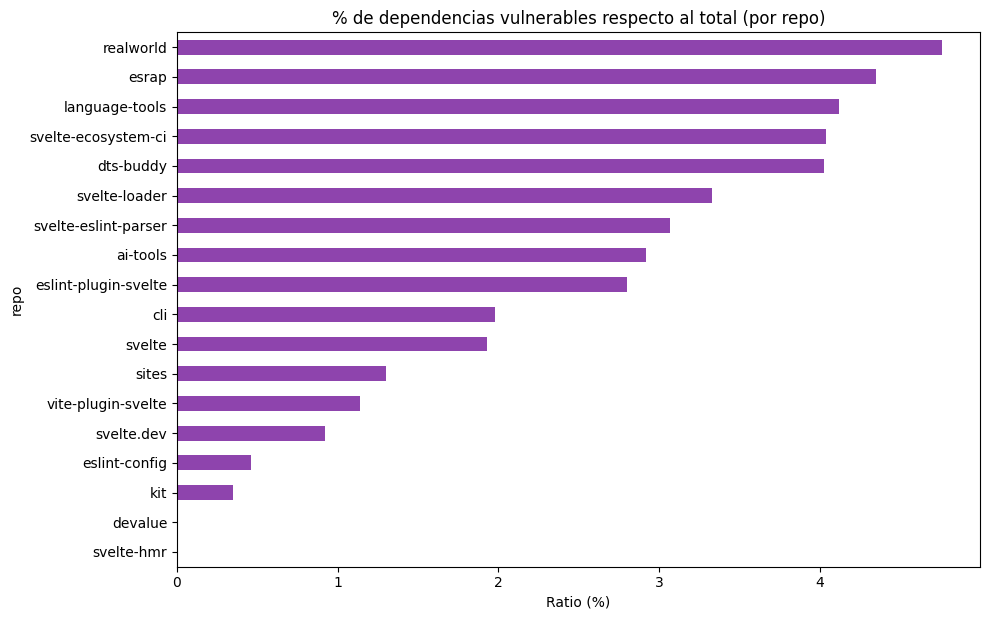

In [181]:
if df_artefactos.empty or df_vulns.empty:
    print("Se necesitan SBOM y Grype para el cruce.")
else:
    paquetes_sbom = (
        df_artefactos.dropna(subset=["name"])
        .groupby("repo")["name"]
        .nunique()
        .rename("paquetes_sbom")
    )
    paquetes_vulnerables = (
        df_vulns.groupby("repo")["package_name"]
        .nunique()
        .rename("paquetes_vulnerables")
    )
    vulnerabilidades_totales = (
        df_vulns.groupby("repo").size().rename("vulnerabilidades_totales")
    )

    cruce = (
        pd.concat(
            [paquetes_sbom, paquetes_vulnerables, vulnerabilidades_totales],
            axis=1,
        )
        .fillna(0)
        .astype(int)
    )
    cruce["ratio_pct"] = (
        cruce["paquetes_vulnerables"]
        / cruce["paquetes_sbom"].replace(0, pd.NA)
        * 100
    ).round(2)
    cruce = cruce.sort_values("ratio_pct", ascending=False)
    display(cruce)

    grafico = cruce.dropna(subset=["ratio_pct"]).sort_values("ratio_pct")
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(grafico))))
    grafico["ratio_pct"].plot(kind="barh", ax=ax, color="#8e44ad")
    ax.set_title("% de dependencias vulnerables respecto al total (por repo)")
    ax.set_xlabel("Ratio (%)")
    plt.tight_layout()
    plt.show()

In [182]:
print(f"Repositorios con SBOM:     {len(sbom_files)}")
print(f"Repositorios con Grype:    {len(grype_files)}")
print(f"Repositorios con CodeQL:   {len(codeql_files)}")
print()
print(f"Artefactos SBOM totales:         {len(df_artefactos):>7}")
print(f"Vulnerabilidades Grype totales:  {len(df_vulns):>7}")
print(f"Hallazgos CodeQL totales:        {len(df_codeql):>7}")
if not df_vulns.empty:
    criticas = (df_vulns["vuln_severity"].str.lower() == "critical").sum()
    altas = (df_vulns["vuln_severity"].str.lower() == "high").sum()
    print()
    print(
        f"Vulnerabilidades bajas:    {(df_vulns['vuln_severity'].str.lower() == 'low').sum()}")
    print(f"Vulnerabilidades críticas: {criticas}")
    print(f"Vulnerabilidades altas:    {altas}")
if not df_codeql.empty:
    errores = (df_codeql["level"].str.lower() == "error").sum()
    print(f"Hallazgos CodeQL 'error':  {errores}")

Repositorios con SBOM:     18
Repositorios con Grype:    18
Repositorios con CodeQL:   18

Artefactos SBOM totales:            7769
Vulnerabilidades Grype totales:      376
Hallazgos CodeQL totales:           2408

Vulnerabilidades bajas:    376
Vulnerabilidades críticas: 0
Vulnerabilidades altas:    0
Hallazgos CodeQL 'error':  0


<a id="seccion-7"></a>
## 6. Análisis de los resultados

Tras procesar los 18 repositorios de la organización **sveltejs**, las tres herramientas entregaron volúmenes muy distintos. Syft identificó 7.769 artefactos entre dependencias, workflows y archivos de manifest. Grype detectó 376 vulnerabilidades dentro de esas dependencias. CodeQL, que analiza directamente el código fuente, produjo 2.408 hallazgos.

Lo más notable es la severidad. Las 376 vulnerabilidades reportadas por Grype son todas de severidad `low`, sin un solo caso marcado como `critical` o `high`. Del lado de CodeQL ocurre algo parecido, sonde los 2.408 hallazgos están clasificados como `warning` o `note`, y ninguno alcanza el nivel `error`. Además, Grype no entregó puntajes CVSS distintos de cero.


El ecosistema está fuertemente concentrado en JavaScript y TypeScript, con la licencia MIT como dominante. Esto es coherente con un proyecto web open source y no presenta sorpresas.

Lo que sí aporta información es la sección 2.4 (Dependencias compartidas entre repositorios). Las acciones de GitHub `actions/checkout` y `actions/setup-node` aparecen en 16 de los 18 repositorios, y utilidades como `picomatch`, `prettier`, `semver`, `acorn`, `magic-string`, `typescript` y varias del scope `@jridgewell` aparecen en 15 repos cada una. Son las piezas comunes del ecosistema de la empresa Svelte y por lo tanto son exactamente donde conviene poner atención en los analisis de seguridad.


Los paquetes que concentran más vulnerabilidades son, en la mayoría de los casos, los mismos que están más compartidos entre repos. Los que destacan:

- `minimatch` con 56 vulnerabilidades distribuidas en 7 repos.
- `picomatch` con 42 vulnerabilidades en 11 repos.
- `vite` con 35 vulnerabilidades en 8 repos.
- `brace-expansion` con 24 vulnerabilidades en 10 repos.
- `svelte` y `@sveltejs/kit` con 23 y 18 vulnerabilidades respectivamente.

Este patrón implica actualizar uno solo de estos paquetes tendría un efecto mayor, porque arreglarlo en un lugar beneficia a todos los repos que dependen de él. 


Las reglas que más se disparan son de calidad de código, no de seguridad crítica. `js/useless-expression` produce 1.233 hallazgos distribuidos en 7 repos, `js/unused-local-variable` aporta otros 683 en 12 repos, y `js/useless-assignment-to-local` suma 92 más. Son, en su mayoría, oportunidades de limpieza, código muerto, variables que no se usan, expresiones que no producen efecto son lo mas presente.

El repositorio `language-tools` concentra la mayoeia de los hallazgos con 1.592. Una parte importante de esos hallazgos se explican por el hecho de que el repo contiene archivos de test que generan deliberadamente patrones que disparan las reglas.

### Conclusión

El ecosistema **sveltejs** presenta un perfil de seguridad que puede considerarse saludable. No se detectaron vulnerabilidades de severidad alta ni crítica, y tampoco hallazgos CodeQL al nivel `error`. Las 376 vulnerabilidades encontradas, todas de severidad **baja**, están concentradas en un conjunto pequeño de paquetes ampliamente compartidos entre repos, lo que convierte a esos paquetes en el foco para cualquier preocupación de seguridad. Por otro lado, los hallazgos de CodeQL son más útiles como lista de limpieza de código que como alerta de seguridad.
